We're investigating data scraped from allrecipes.com. The data is from 120 recipes from the search results for "cookie" (5 pages with 24 results each). We've got:
* The recipe url and title
* Average rating, and number of ratings
* Recipe details which includes the prep time and yield
* Ingredients

The data is stored in separate files as the scrapy bot was getting blocked when I tried getting them all in one go. So let's load the data and combine the pages into a single dataframe.

In [35]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATADIR = Path('cookie_recipes', 'webdata')

recipe_dataframes = []
for datafile in DATADIR.glob('allrecipes*.json'):
    df = pd.read_json(datafile)
    recipe_dataframes.append(df)

recipe_dataframe = pd.concat(recipe_dataframes)

## Check the column names
recipe_dataframe.columns

Index(['recipe_url', 'title', 'avg_rating', 'num_ratings', 'recipe_details',
       'ingredients'],
      dtype='str')

## Ratings
Let's look at the ratings. Below we have plotted the number of ratings versus the average rating. 

The stripes in the plot are due to the ratings all being values with exactly one decimal place. That's due to the numbers being taken from the website directly as displayed, it's not a calculated average value.

The ratings are all between 4.0 and 4.8 (this is out of 5) which suggests that the data isn't the complete set of "cookie" recipes, as surely there would be ones rated below 4.0. That claim is suppported by the results fitting five pages exactly (5 x 24 = 120), instead of the last page being partially filled. Likely, allrecipes will place a cutoff on search results at 120 recipes, based on average rating, number of ratings, or a combination of both.

Lastly, the data show a trend where the rating tends toward 4.6 as the number of ratings get higher. Or in any case, allrecipes does show search results for recipes rated on the lower end (4.0 - 4.4), but not ones that also have a large number of reviews. I suspect that on the high end (rating 4.7 and 4.8), this is a real effect: When the number of ratings increases (> 10,000), there will be enough low or low-ish ratings to make the average drop slightly.

### Further research
To find out more about allrecipes cutoff on search results and/or the "real" distribution of average ratings, we could for example try a more specific search term. Searching for, say, "chocolote chip cookie" should yield results from a smaller subset of ALL recipes. We could try making the querie more-and-more specific, until we find that there are less than 120 total results, which would indicate that we have a complete subset. (Ideally, being just below 120 results).

Better yet would be to somehow get around the cutoff on search results and just get "more data". FYI, there aren't any filter options on allrecipes, so we couldn't directly request recipes rated below 4.0. (That also would still leave us with a potentially biased subset). But I have an idea...

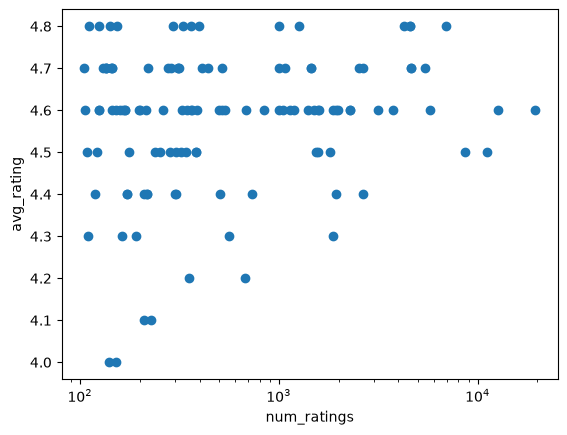

In [31]:
ratings = recipe_dataframe[["avg_rating", "num_ratings"]].sort_values(by = "num_ratings")

fig, ax = plt.subplots()
ax.set_xscale('log')
ax.set_xlabel("num_ratings")
ax.set_ylabel("avg_rating")
ax.scatter(ratings["num_ratings"], ratings["avg_rating"])



## More DATA!

...I noticed that the urls for the results pages (except the first) have a query parameter `offset=[N]`, where N=24 for the second page, 48 for the third, 72 for the fourth, and 96 for the sixth. There isn't a *button* to go to page six, but if we just put `offset=120` into the url that actually gives us a new page of results! Neat. 

So anyway I started jamming numbers into the url just to see how many results there really were. At offset=7000 there results are less "cookie recipe" and more "What is Demerara Sugar and How Can You Use It?" At offset=8100 we get classic cookies such as "22 Best Savory Lemon Recipes for Dinner". At offset=8190 I get a results page with only four results on it, so we must conclude there are a total of 8194 search results for "cookie" on allrecipes.

In [36]:
recipe_dataframe[recipe_dataframe["title"]=="Italian Cookies"]

,recipe_url,title,avg_rating,num_ratings,recipe_details,ingredients
23,https://www.allrecipes.com/recipe/9826/italian...,Italian Cookies,4.6,145,"{'prep_time': '25 mins', 'cook_time': '10 mins...","[{'quantity': '3', 'unit': 'cups', 'name': 'al..."
